# Theory

Min and max filters are nonlinear spatial filters used in image processing for noise reduction and feature enhancement. The **min filter** replaces each pixel value in an image with the minimum value from its neighborhood, effectively removing bright outlier pixels (salt noise) and preserving dark regions. Conversely, the **max filter** replaces each pixel with the maximum value from its neighborhood, removing dark outlier pixels (pepper noise) and preserving bright regions.

Mathematically, for a given pixel at position $(i, j)$ and a neighborhood $N(i, j)$:
- **Min filter:** $g(i, j) = \min\limits_{(s, t) \in N(i, j)} f(s, t)$
- **Max filter:** $g(i, j) = \max\limits_{(s, t) \in N(i, j)} f(s, t)$

where $f(s, t)$ is the input image and $g(i, j)$ is the filtered output.



In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def min_filter(input_image):
  img = input_image.resize((400,400), Image.Resampling.LANCZOS)

  fig = plt.figure()
  fig.set_figheight(20)
  fig.set_figwidth(20)

  #plotting original image
  fig.add_subplot(1,2,1)
  plt.imshow(img, cmap='gray')
  plt.title('original')


  # convert to numpy array 
  numpy_image = np.array(img)
  # array for padding
  array_b = np.zeros((402,402))

  # to pad initial array with zeros in all side
  array_b[1:401,1:401] = numpy_image

  #defining filter
  #filter_array = np.array([[1,1,1],
   #                        [1,1,1],
    #                       [1,1,1]])
  
  filter_array = np.array([[3,3,3],
                           [3,3,3],
                           [3,3,3]])
  
  #creating empty list
  lst = []

  for i in range(400):
    for j in range(400):
      #extracting part of array equal to filter size
      array_c = array_b[i:(3+i),j:(3+j)]
    
     #applying filter
      array_mul = np.multiply(filter_array,array_c)
      array_sum = np.min(array_mul)
    
      # putting calculated value in list
      lst.append(array_sum)

  # resizing lst to shape of original array
  final_array = np.resize(lst,(400,400))

  final_image = Image.fromarray(final_array)
  final_image= final_image.convert("L")

    #plotting filtered image
  fig.add_subplot(1,2,2)
  plt.imshow(final_image, cmap='gray')
  plt.title('Min image')
  

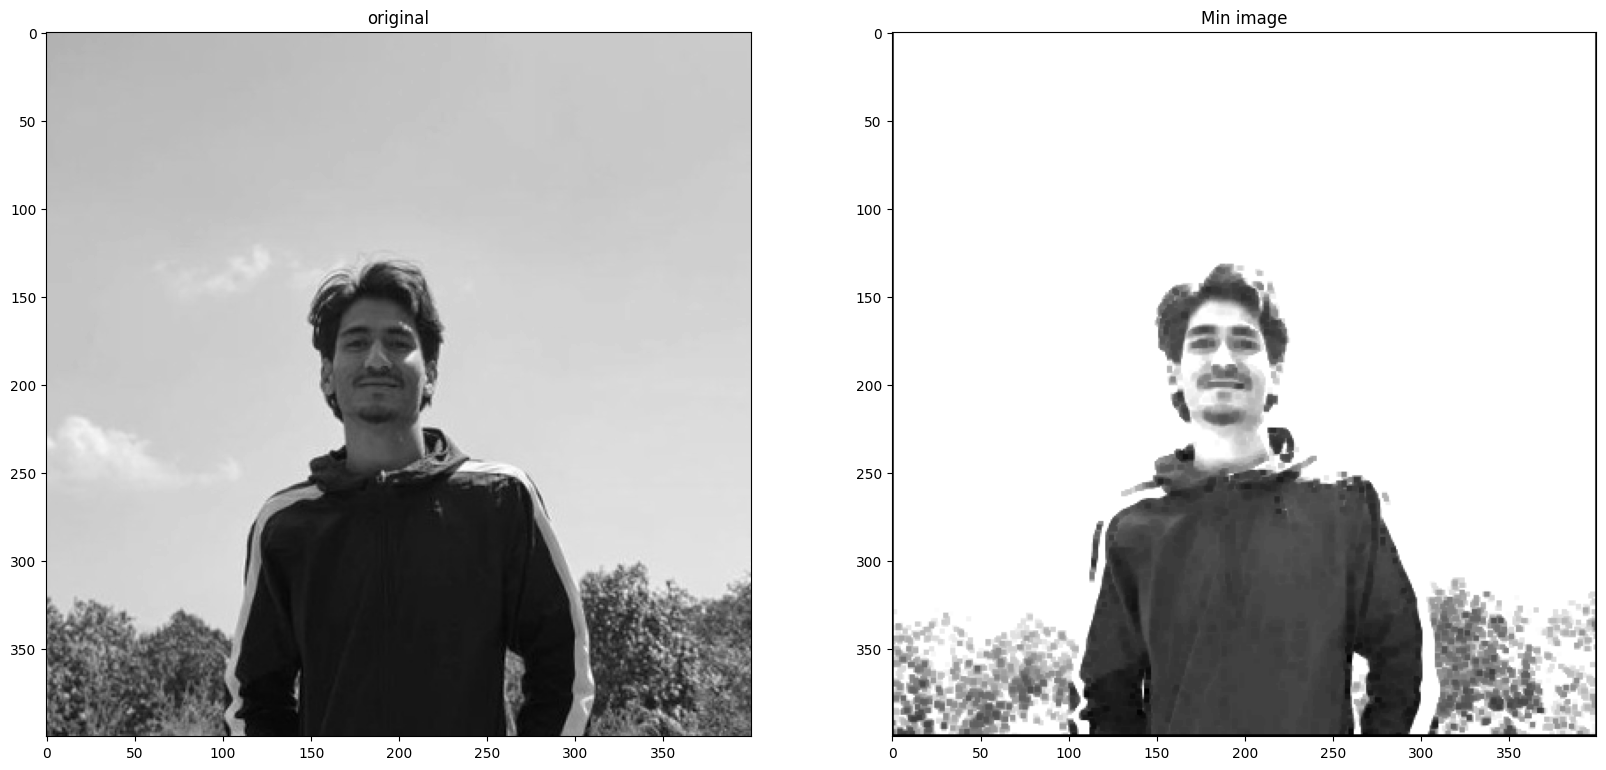

In [3]:
# reading image and converting to gray scale
img = Image.open('img/prakash.jpg').convert('L')
# Call filter function
min_filter(img)

In [4]:
def max_filter(input_image):
  img = input_image.resize((400,400), Image.Resampling.LANCZOS)

  fig = plt.figure()
  fig.set_figheight(20)
  fig.set_figwidth(20)

  #plotting original image
  fig.add_subplot(1,2,1)
  plt.imshow(img, cmap='gray')
  plt.title('original')


  # convert to numpy array 
  numpy_image = np.array(img)
  # array for padding
  array_b = np.zeros((402,402))

  # to pad initial array with zeros in all side
  array_b[1:401,1:401] = numpy_image

  #defining filter
  #filter_array = np.array([[1,1,1],
   #                        [1,1,1],
    #                       [1,1,1]])
  
  filter_array = np.array([[3,3,3],
                           [3,3,3],
                           [3,3,3]])
  
  #creating empty list
  lst = []

  for i in range(400):
    for j in range(400):
      #extracting part of array equal to filter size
      array_c = array_b[i:(3+i),j:(3+j)]
    
     #applying filter
      array_mul = np.multiply(filter_array,array_c)
      array_sum = np.max(array_mul)
    
      # putting calculated value in list
      lst.append(array_sum)

  # resizing lst to shape of original array
  final_array = np.resize(lst,(400,400))

  final_image = Image.fromarray(final_array)
  final_image= final_image.convert("L")

    #plotting filtered image
  fig.add_subplot(1,2,2)
  plt.imshow(final_image, cmap='gray')
  plt.title('Max image')
  

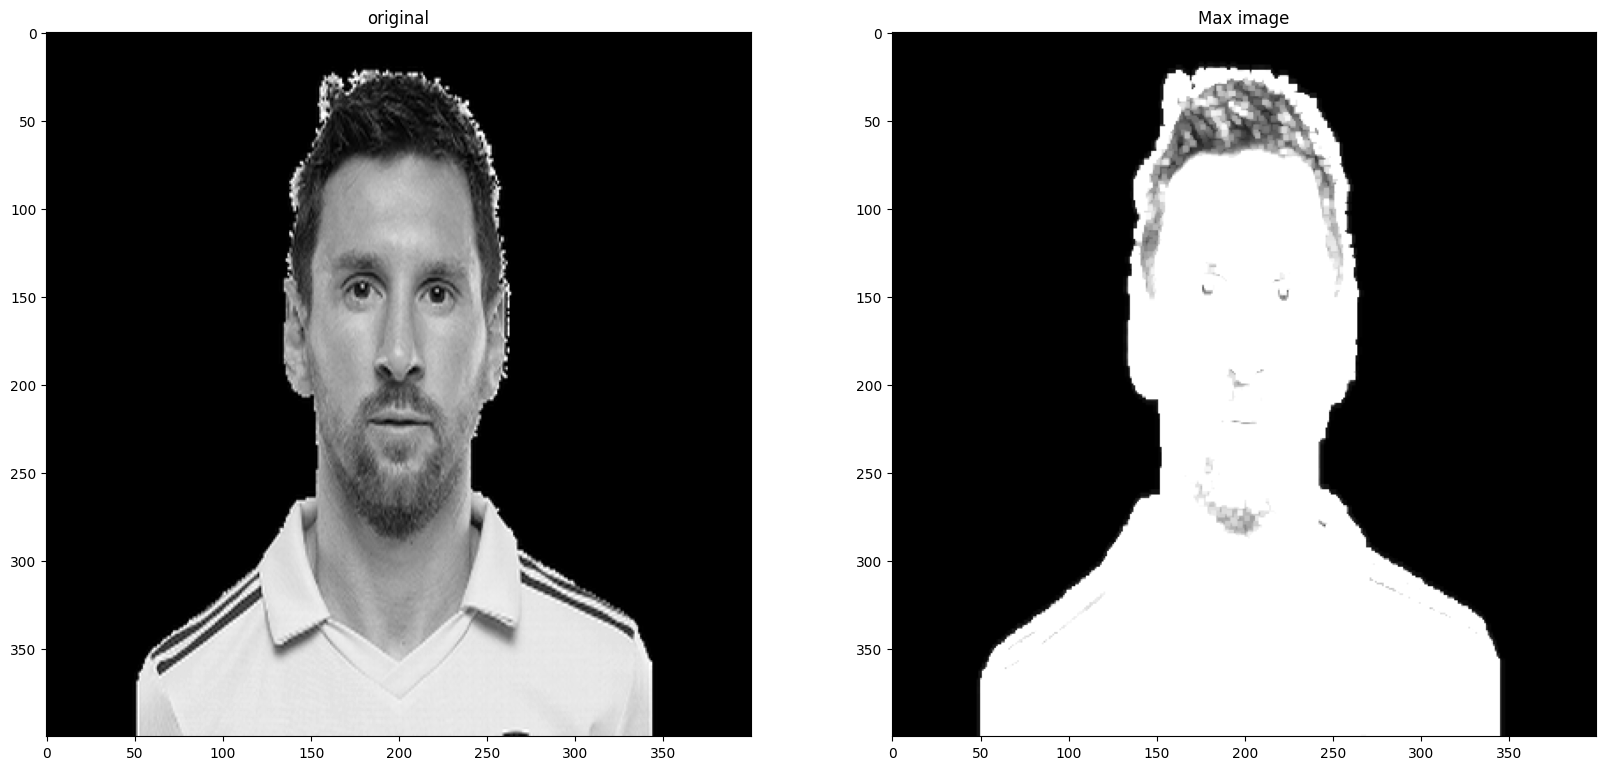

: 

In [ ]:
# reading image and converting to gray scale
img = Image.open('img/tiger.png').convert('L')
# Call max filter function
max_filter(img)

# Conclusion

By applying min and max filters to grayscale images, we observe that:
- The **min filter** smooths the image and removes bright noise, but may also erode fine bright details.
- The **max filter** enhances bright regions and removes dark noise, but may expand bright features.

These filters are effective for basic noise removal and morphological operations, but may not preserve all image details. The choice of filter depends on the type of noise and the desired outcome in image preprocessing tasks.